In [1]:
# 1. 레포 클론 및 설치
!git clone https://github.com/amazon-research/patchcore-inspection.git
!git clone https://github.com/DonaldRR/SimpleNet.git
!pip install -r /content/patchcore-inspection/requirements.txt
!pip install -e /content/patchcore-inspection
!pip install faiss-cpu

Cloning into 'patchcore-inspection'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 365 (delta 13), reused 8 (delta 8), pack-reused 329 (from 1)
Receiving objects: 100% (365/365), 2.02 MiB | 18.31 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Filtering content: 100% (360/360), 2.14 GiB | 56.32 MiB/s, done.
Cloning into 'SimpleNet'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 95 (delta 42), reused 31 (delta 31), pack-reused 39 (from 1)
Receiving objects: 100% (95/95), 235.91 KiB | 10.72 MiB/s, done.
Resolving deltas: 100% (47/47), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 15.8 MB/s eta 0:00:00
  Created wheel for pretrainedmodels: filen

In [2]:
# 2. Google Drive 마운트 및 데이터 압축 해제
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/mvtec_data/archive.zip "screw/*" -d /content/mvtec_data

Mounted at /content/drive
Archive:  /content/drive/MyDrive/mvtec_data/archive.zip
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/000_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/001_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/002_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/003_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/004_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/005_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/006_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/007_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/008_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_front/009_mask.png  
  inflating: /content/mvtec_data/screw/ground_truth/manipulated_fron

In [3]:
# 3. SimpleNet metrics.py 패치 (deprecated 코드 수정)
with open('/content/SimpleNet/metrics.py', 'r') as f:
    content = f.read()

content = content.replace(
    'df = df.append({"pro": np.mean(pros), "fpr": fpr, "threshold": th}, ignore_index=True)',
    'df = pd.concat([df, pd.DataFrame([{"pro": np.mean(pros), "fpr": fpr, "threshold": th}])], ignore_index=True)'
)

with open('/content/SimpleNet/metrics.py', 'w') as f:
    f.write(content)

print("SimpleNet metrics.py 수정 완료!")

SimpleNet metrics.py 수정 완료!


In [4]:
# 4. PatchCore run_patchcore.py 패치 (transform 오류 수정)
with open('/content/patchcore-inspection/bin/run_patchcore.py', 'r') as f:
    content = f.read()

content = content.replace(
    'dataloaders["testing"].dataset.transform_mean',
    '[0.485, 0.456, 0.406]'
)
content = content.replace(
    'dataloaders["testing"].dataset.transform_std',
    '[0.229, 0.224, 0.225]'
)

with open('/content/patchcore-inspection/bin/run_patchcore.py', 'w') as f:
    f.write(content)

print("PatchCore run_patchcore.py 수정 완료!")

PatchCore run_patchcore.py 수정 완료!


In [6]:
# 5. PatchCore 실행 (screw)
%cd /content/patchcore-inspection
!python bin/run_patchcore.py \
    --gpu 0 \
    --seed 0 \
    results/mvtec_results \
    patch_core \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1024 \
    --target_embed_dimension 1024 \
    --anomaly_scorer_num_nn 1 \
    --patchsize 3 \
    sampler \
    -p 0.1 \
    approx_greedy_coreset \
    dataset \
    --resize 256 \
    --imagesize 224 \
    -d screw \
    mvtec \
    /content/mvtec_data

/content/patchcore-inspection
INFO:__main__:Command line arguments: bin/run_patchcore.py --gpu 0 --seed 0 results/mvtec_results patch_core -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1024 --target_embed_dimension 1024 --anomaly_scorer_num_nn 1 --patchsize 3 sampler -p 0.1 approx_greedy_coreset dataset --resize 256 --imagesize 224 -d screw mvtec /content/mvtec_data
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:__main__:Evaluating dataset [mvtec_screw] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: Use

In [5]:
# 6. SimpleNet 실행 (screw, epoch 160)
%cd /content/SimpleNet
!python main.py \
    --results_path results \
    --gpu 0 \
    dataset --subdatasets screw mvtec /content/mvtec_data \
    net \
    -b wideresnet50 \
    -le layer2 -le layer3 \
    --meta_epochs 160 \
    --gan_epochs 4

/content/SimpleNet
2026-05-06 05:43:32.246796: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:Command line arguments: main.py --results_path results --gpu 0 dataset --subdatasets screw mvtec /content/mvtec_data net -b wideresnet50 -le layer2 -le layer3 --meta_epochs 160 --gan_epochs 4
INFO:__main__:Dataset: train=320 test=160
INFO:__main__:Evaluating dataset [mvtec_screw] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for '

사용 디바이스: cuda
PatchCore 메모리 뱅크 완료: torch.Size([250880, 1536])


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1`. You can also use `weights=Wide_ResNet50_2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SimpleNet 모델 로드 완료!


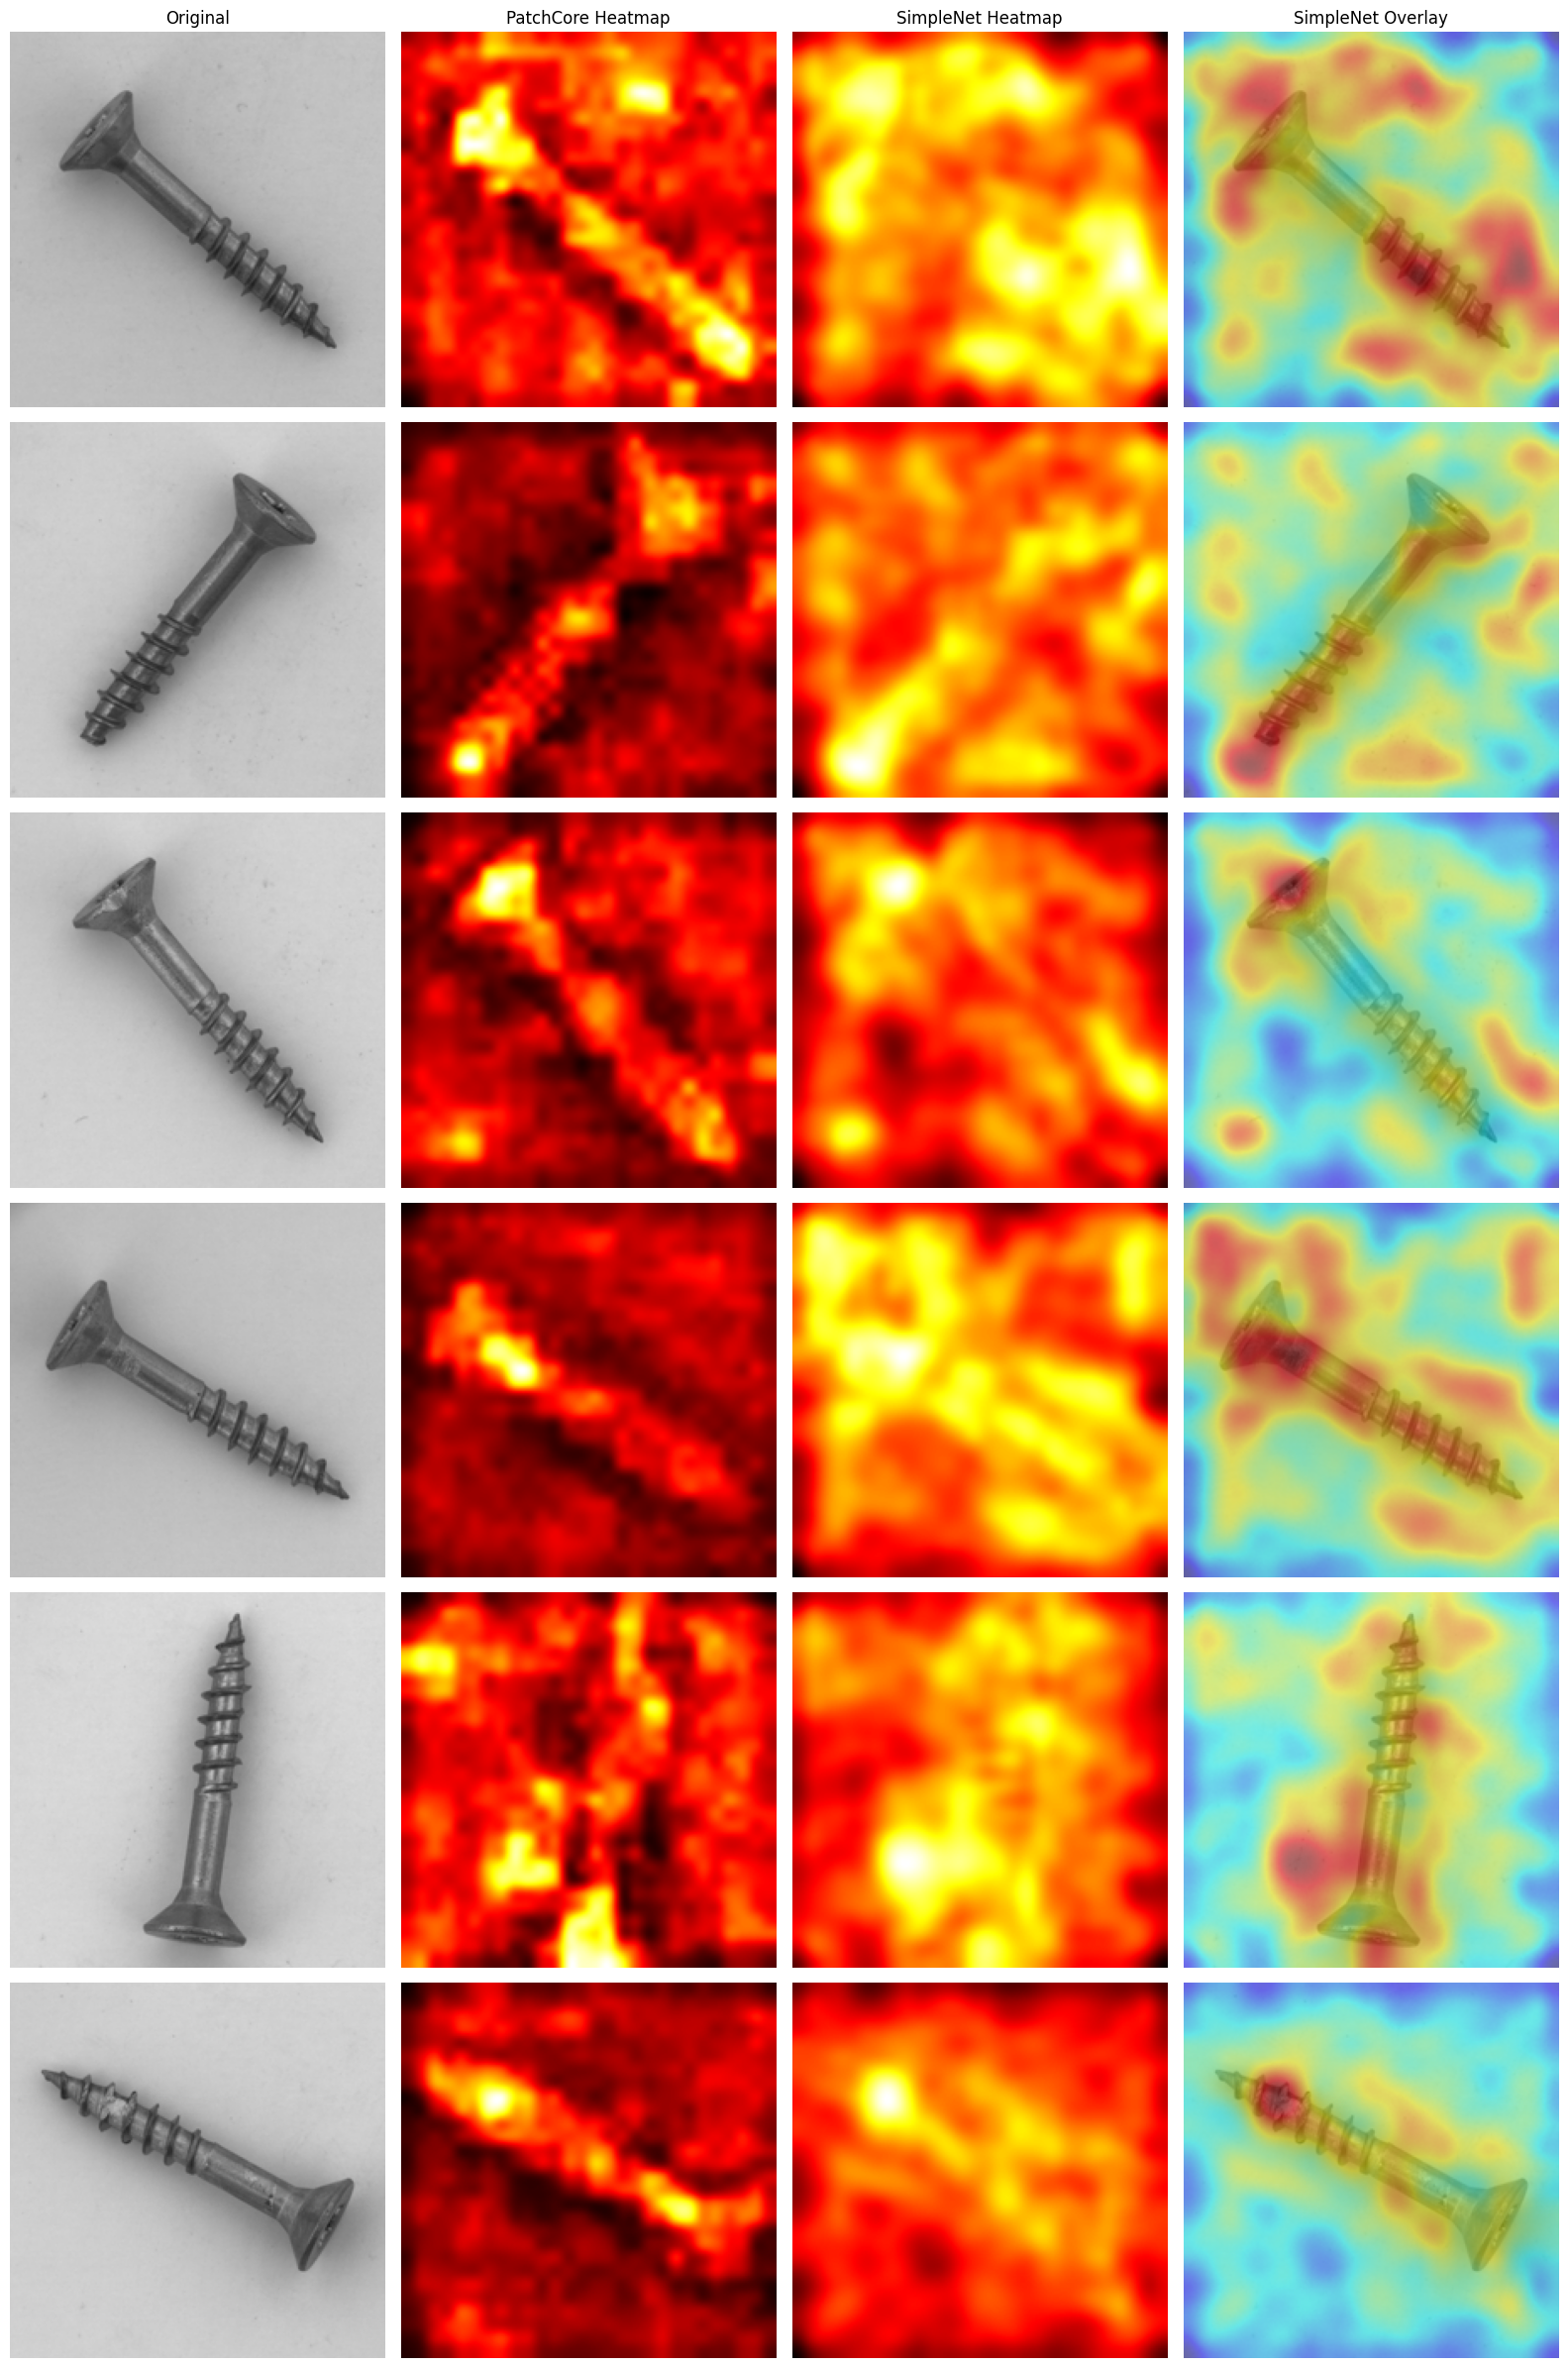

시각화 완료!


In [7]:
# 7. 시각화 (두 모델 히트맵 비교)
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F
import sys
import cv2
sys.path.append('/content/SimpleNet')
import simplenet
import backbones

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# PatchCore 메모리 뱅크 구성
backbone_pc = models.wide_resnet50_2(weights="IMAGENET1K_V1").to(device)
backbone_pc.eval()
features_layer2, features_layer3 = [], []

def hook2(m, i, o): features_layer2.append(o.detach())
def hook3(m, i, o): features_layer3.append(o.detach())

backbone_pc.layer2.register_forward_hook(hook2)
backbone_pc.layer3.register_forward_hook(hook3)

train_path = "/content/mvtec_data/screw/train/good"
train_features = []
for img_name in sorted(os.listdir(train_path)):
    img = Image.open(os.path.join(train_path, img_name)).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    features_layer2.clear(); features_layer3.clear()
    with torch.no_grad():
        backbone_pc(img_tensor)
    f2 = F.adaptive_avg_pool2d(features_layer2[0], (28, 28))
    f3 = F.adaptive_avg_pool2d(features_layer3[0], (28, 28))
    feat = torch.cat([f2, f3], dim=1).squeeze(0)
    feat = feat.permute(1, 2, 0).reshape(-1, feat.shape[0])
    train_features.append(feat)
memory_bank = torch.cat(train_features, dim=0).cpu()
print(f"PatchCore 메모리 뱅크 완료: {memory_bank.shape}")

# SimpleNet 모델 로드
sn_model = simplenet.SimpleNet(device)
sn_model.load(
    backbone=backbones.load('wideresnet50'),
    layers_to_extract_from=['layer2', 'layer3'],
    device=device,
    input_shape=(3, 224, 224),
    pretrain_embed_dimension=1536,
    target_embed_dimension=1024,
    dsc_hidden=682,
)
ckpt = torch.load('/content/SimpleNet/results/project/group/test/models/0/mvtec_screw/ckpt.pth', map_location=device)
sn_model.discriminator.load_state_dict(ckpt['discriminator'])
print("SimpleNet 모델 로드 완료!")

# 시각화
test_base = "/content/mvtec_data/screw/test"
defect_types = sorted([d for d in os.listdir(test_base) if os.path.isdir(os.path.join(test_base, d))])

fig, axes = plt.subplots(len(defect_types), 4, figsize=(16, 4*len(defect_types)))
cols = ['Original', 'PatchCore Heatmap', 'SimpleNet Heatmap', 'SimpleNet Overlay']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=12)

for row, defect in enumerate(defect_types):
    defect_path = os.path.join(test_base, defect)
    img_path = os.path.join(defect_path, sorted(os.listdir(defect_path))[0])
    orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_tensor = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

    # PatchCore 히트맵
    features_layer2.clear(); features_layer3.clear()
    with torch.no_grad():
        backbone_pc(img_tensor)
    f2 = F.adaptive_avg_pool2d(features_layer2[0], (28, 28))
    f3 = F.adaptive_avg_pool2d(features_layer3[0], (28, 28))
    feat = torch.cat([f2, f3], dim=1).squeeze(0)
    test_patches = feat.permute(1, 2, 0).reshape(-1, feat.shape[0]).cpu()
    dists = torch.cdist(test_patches, memory_bank)
    min_dists, _ = dists.min(dim=1)
    pc_map = min_dists.reshape(28, 28).numpy()
    pc_map = np.array(Image.fromarray(pc_map).resize((224, 224)))
    pc_map = (pc_map - pc_map.min()) / (pc_map.max() - pc_map.min() + 1e-8)

    # SimpleNet 히트맵
    _, sn_masks, _ = sn_model._predict(img_tensor)
    sn_map = np.array(sn_masks[0])
    sn_map = (sn_map - sn_map.min()) / (sn_map.max() - sn_map.min() + 1e-8)

    # 오버레이
    sn_color = cv2.applyColorMap((sn_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
    sn_color = cv2.cvtColor(sn_color, cv2.COLOR_BGR2RGB)
    overlay = (np.array(orig_img) * 0.5 + sn_color * 0.5).astype(np.uint8)

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_ylabel(defect, fontsize=10)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(pc_map, cmap='hot')
    axes[row, 1].axis("off")
    axes[row, 2].imshow(sn_map, cmap='hot')
    axes[row, 2].axis("off")
    axes[row, 3].imshow(overlay)
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig("comparison_screw.png", dpi=150, bbox_inches="tight")
plt.show()
print("시각화 완료!")